# 03 — Dataset Analysis (Full Period)

**Goal:** Analyze the supervised and unsupervised datasets across the **full period** (Jun 2024 – Jun 2025), not just failure events. Understand anomaly score patterns, temporal dynamics, and subsystem discriminability.

**Sections:**
1. Data loading (train+test, RF + LSTM-AE)
2. Full-period anomaly timeline
3. Score distributions — train vs test, by month
4. Anomaly hotspot detection — sustained high-score periods
5. Subsystem-level feature discriminability (Cohen's d)
6. Within-subsystem correlation analysis (normal vs failure)
7. Unsupervised data: standardization & channel checks
8. Temporal coverage & operational patterns

In [1]:
import sys, os, glob, gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
ROOT = os.path.abspath('..')
OUT_DIR = os.path.join(ROOT, 'outputs')

# Constants
WINDOW_S = 350
HORIZON_S = 22326
SEQ_WINDOW_S = 1402
SUBSAMPLE = 4
seq_len_sub = SEQ_WINDOW_S // SUBSAMPLE  # 350
n_channels = 95
TS_COL = 'TIMESTAMP'
FAIL_COL = 'TRAIN_IS_IN_FAILURE'
FAIL_TYPE = 'TRAIN_FAILURE_TYPE'
MAINT_COL = 'TRAIN_IS_IN_MAINTENANCE'
SPLIT_DATE = pd.Timestamp('2025-02-12')

print('Setup complete')

Setup complete


## 1. Data Loading — Full Period

Load RF predictions on both train and test windows, plus LSTM-AE scores on full period.

In [2]:
# ── Load supervised data and RF model ──
saved = joblib.load(os.path.join(OUT_DIR, 'supervised', 'rf_model.joblib'))
rf_model = saved['model']
RF_THR = saved['threshold']

train_sup = pd.read_parquet(os.path.join(OUT_DIR, 'supervised', 'train.parquet'))
test_sup = pd.read_parquet(os.path.join(OUT_DIR, 'supervised', 'test.parquet'))

train_sup['window_end'] = pd.to_datetime(train_sup['window_end'])
test_sup['window_end'] = pd.to_datetime(test_sup['window_end'])

feature_cols = [c for c in train_sup.columns if c not in {'timestamp', 'window_end', 'label'}]

# Predict RF probabilities on both splits
train_sup['prob'] = rf_model.predict_proba(train_sup[feature_cols])[:, 1]
train_sup['pred'] = (train_sup['prob'] >= RF_THR).astype(int)
train_sup['fail'] = train_sup['label']
train_sup['split'] = 'train'

test_sup['prob'] = rf_model.predict_proba(test_sup[feature_cols])[:, 1]
test_sup['pred'] = (test_sup['prob'] >= RF_THR).astype(int)
test_sup['fail'] = test_sup['label']
test_sup['split'] = 'test'

# Combine
rf_all = pd.concat([
    train_sup[['window_end', 'prob', 'pred', 'fail', 'split']],
    test_sup[['window_end', 'prob', 'pred', 'fail', 'split']]
]).sort_values('window_end').reset_index(drop=True)

# Keep feature data for later subsystem analysis
rf_train_feats = train_sup[feature_cols + ['label', 'window_end']].copy()
rf_test_feats = test_sup[feature_cols + ['label', 'window_end']].copy()
rf_feats_all = pd.concat([rf_train_feats, rf_test_feats]).sort_values('window_end').reset_index(drop=True)

del train_sup, test_sup; gc.collect()

print(f'RF full period: {len(rf_all):,} windows')
print(f'  Train: {(rf_all["split"]=="train").sum():,} | Test: {(rf_all["split"]=="test").sum():,}')
print(f'  Date range: {rf_all["window_end"].min()} to {rf_all["window_end"].max()}')
print(f'  Failure windows: {rf_all["fail"].sum():,} ({100*rf_all["fail"].mean():.2f}%)')
print(f'  RF threshold: {RF_THR:.3f}')

RF full period: 64,522 windows
  Train: 41,375 | Test: 23,147
  Date range: 2024-06-01 04:41:40 to 2025-07-01 00:04:10
  Failure windows: 1,202 (1.86%)
  RF threshold: 0.200


In [3]:
# ── Load or compute LSTM-AE scores for full period ──
cache_path = os.path.join(OUT_DIR, 'unsupervised', 'full_period_lstmae_scores.parquet')

if os.path.exists(cache_path):
    ae_all = pd.read_parquet(cache_path)
    ae_all['window_end'] = pd.to_datetime(ae_all['window_end'])
    print(f'Loaded cached LSTM-AE scores: {len(ae_all):,} sequences')
else:
    print('Computing LSTM-AE scores for full period (this takes a few minutes)...')
    
    # Load metadata and model
    with open(os.path.join(OUT_DIR, 'unsupervised', 'metadata.json')) as f:
        meta = json.load(f)
    UNSUP_CHANNELS = meta['channels']
    channel_stats = meta['channel_stats']

    class LSTMAutoencoder(nn.Module):
        def __init__(self, nc, hd):
            super().__init__()
            self.encoder = nn.LSTM(nc, hd, batch_first=True)
            self.decoder = nn.LSTM(hd, hd, batch_first=True)
            self.output_layer = nn.Linear(hd, nc)
        def forward(self, x):
            _, (h, c) = self.encoder(x)
            dec_in = h.squeeze(0).unsqueeze(1).repeat(1, x.size(1), 1)
            dec_out, _ = self.decoder(dec_in, (h, c))
            return self.output_layer(dec_out)

    ae_model = LSTMAutoencoder(n_channels, 64)
    ae_model.load_state_dict(torch.load(
        os.path.join(OUT_DIR, 'unsupervised', 'lstm_ae_model.pt'), weights_only=True))
    ae_model.eval()

    def score_split(data_glob, split_name):
        files = sorted(glob.glob(data_glob, recursive=True))
        unsup_cols = [TS_COL, FAIL_COL, MAINT_COL] + UNSUP_CHANNELS
        chunks = []
        for f in files:
            df = pd.read_parquet(f)
            avail = [c for c in unsup_cols if c in df.columns]
            chunks.append(df[avail])
            del df
        raw = pd.concat(chunks, ignore_index=True)
        del chunks; gc.collect()
        raw[TS_COL] = pd.to_datetime(raw[TS_COL])
        raw.sort_values(TS_COL, inplace=True)
        raw.reset_index(drop=True, inplace=True)
        clean = raw[~raw[MAINT_COL].astype(bool)].copy()
        del raw; gc.collect()
        for c in UNSUP_CHANNELS:
            clean[c] = (clean[c] - channel_stats[c]['mean']) / channel_stats[c]['std']
        clean = clean.set_index(TS_COL).sort_index()
        resampler = clean.resample(f'{SEQ_WINDOW_S}s', origin='epoch')

        times, labels, seqs = [], [], []
        for ws, group in resampler:
            if len(group) < int(SEQ_WINDOW_S * 0.8):
                continue
            vals = group[UNSUP_CHANNELS].values
            if len(vals) >= SEQ_WINDOW_S:
                sub = vals[::SUBSAMPLE][:seq_len_sub]
            else:
                x_old = np.linspace(0, 1, len(vals))
                x_new = np.linspace(0, 1, SEQ_WINDOW_S)
                full = np.zeros((SEQ_WINDOW_S, n_channels), dtype=np.float32)
                for ch in range(n_channels):
                    full[:, ch] = np.interp(x_new, x_old, vals[:, ch])
                sub = full[::SUBSAMPLE][:seq_len_sub]
            if len(sub) < seq_len_sub:
                sub = np.vstack([sub, np.zeros((seq_len_sub - len(sub), n_channels), dtype=np.float32)])
            seqs.append(np.nan_to_num(sub, 0.0).astype(np.float32))
            times.append(ws + pd.Timedelta(seconds=SEQ_WINDOW_S))
            has_fail = group[FAIL_COL].astype(bool).any() if FAIL_COL in group.columns else False
            labels.append(int(has_fail))
        del clean; gc.collect()

        seqs_arr = np.array(seqs, dtype=np.float32)
        loader = DataLoader(TensorDataset(torch.FloatTensor(seqs_arr), torch.FloatTensor(seqs_arr)), batch_size=128)
        errors = []
        with torch.no_grad():
            for xb, _ in loader:
                recon = ae_model(xb)
                errors.append(((xb - recon) ** 2).mean(dim=(1, 2)).numpy())
        scores = np.concatenate(errors)
        result = pd.DataFrame({'window_end': times, 'score': scores, 'fail': labels, 'split': split_name})
        print(f'  {split_name}: {len(result):,} sequences ({result["fail"].sum()} failure)')
        return result

    ae_train = score_split(os.path.join(ROOT, 'train', '**', '*.parquet'), 'train')
    ae_test = score_split(os.path.join(ROOT, 'test', '**', '*.parquet'), 'test')
    ae_all = pd.concat([ae_train, ae_test], ignore_index=True)
    ae_all['window_end'] = pd.to_datetime(ae_all['window_end'])
    ae_all = ae_all.sort_values('window_end').reset_index(drop=True)
    ae_all.to_parquet(cache_path, index=False)
    print(f'Saved cache: {cache_path}')
    del ae_train, ae_test, ae_model; gc.collect()

print(f'\nLSTM-AE full period: {len(ae_all):,} sequences')
print(f'  Train: {(ae_all["split"]=="train").sum():,} | Test: {(ae_all["split"]=="test").sum():,}')
print(f'  Date range: {ae_all["window_end"].min()} to {ae_all["window_end"].max()}')
print(f'  Failure sequences: {ae_all["fail"].sum()} ({100*ae_all["fail"].mean():.2f}%)')

Loaded cached LSTM-AE scores: 15,246 sequences

LSTM-AE full period: 15,246 sequences
  Train: 9,872 | Test: 5,374
  Date range: 2024-06-01 05:11:10 to 2025-06-30 23:58:48
  Failure sequences: 111 (0.73%)


In [4]:
# ── Extract ALL failure events (train+test) from raw data ──
all_files = sorted(
    glob.glob(os.path.join(ROOT, 'train', '**', '*.parquet'), recursive=True) +
    glob.glob(os.path.join(ROOT, 'test', '**', '*.parquet'), recursive=True)
)
chunks = []
for f in all_files:
    df = pd.read_parquet(f, columns=[TS_COL, FAIL_COL, FAIL_TYPE, MAINT_COL])
    chunks.append(df)
raw_meta = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()

raw_meta[TS_COL] = pd.to_datetime(raw_meta[TS_COL])
raw_meta.sort_values(TS_COL, inplace=True)

# Extract failure event blocks
mask = raw_meta[FAIL_COL].astype(bool)
grp = (mask != mask.shift()).cumsum()
fail_events = (
    raw_meta[mask].groupby(grp[mask])
    .agg(start=(TS_COL, 'min'), end=(TS_COL, 'max'),
         event_type=(FAIL_TYPE, 'first'), n_rows=(TS_COL, 'count'))
    .reset_index(drop=True)
)

# Merge nearby events of same type (within 1h)
merged = []
for _, row in fail_events.iterrows():
    if merged and row['event_type'] == merged[-1]['event_type'] and \
       (row['start'] - merged[-1]['end']).total_seconds() < 3600:
        merged[-1]['end'] = row['end']
        merged[-1]['n_rows'] += row['n_rows']
    else:
        merged.append(dict(row))
fail_events_all = pd.DataFrame(merged)
fail_events_all['duration_min'] = (fail_events_all['end'] - fail_events_all['start']).dt.total_seconds() / 60
fail_events_all['period'] = fail_events_all['start'].apply(lambda x: 'train' if x < SPLIT_DATE else 'test')

# Also extract maintenance periods
maint_mask = raw_meta[MAINT_COL].astype(bool)
maint_grp = (maint_mask != maint_mask.shift()).cumsum()
maint_events = (
    raw_meta[maint_mask].groupby(maint_grp[maint_mask])
    .agg(start=(TS_COL, 'min'), end=(TS_COL, 'max'), n_rows=(TS_COL, 'count'))
    .reset_index(drop=True)
)
maint_events['duration_min'] = (maint_events['end'] - maint_events['start']).dt.total_seconds() / 60

del raw_meta; gc.collect()

print(f'All failure events (merged): {len(fail_events_all)}')
print(f'  Train: {(fail_events_all["period"]=="train").sum()} | Test: {(fail_events_all["period"]=="test").sum()}')
print(f'Maintenance periods: {len(maint_events)}')
print(f'\nFailure events:')
print(fail_events_all[['start', 'end', 'event_type', 'duration_min', 'period']].to_string(index=False))

All failure events (merged): 21
  Train: 10 | Test: 11
Maintenance periods: 18

Failure events:
              start                 end                event_type  duration_min period
2024-06-27 15:47:30 2024-06-27 17:52:28      Brake System Failure    124.966667  train
2024-08-19 10:37:51 2024-08-19 11:05:44      Brake System Failure     27.883333  train
2024-08-27 15:58:43 2024-08-28 21:29:25   Leveling System Failure   1770.700000  train
2024-09-03 05:04:00 2024-09-03 07:33:36      Brake System Failure    149.600000  train
2024-09-22 05:49:43 2024-09-22 08:14:45      Brake System Failure    145.033333  train
2024-10-06 02:04:15 2024-10-08 09:15:36      Brake System Failure   3311.350000  train
2024-10-10 11:19:48 2024-10-10 15:35:49      Brake System Failure    256.016667  train
2024-10-31 15:08:06 2024-10-31 18:26:02 Compressor Module Failure    197.933333  train
2024-12-14 18:56:40 2024-12-14 23:31:05      Brake System Failure    274.416667  train
2025-01-21 06:11:15 2025-01-21 09:

## 2. Full-Period Anomaly Timeline

RF probability and LSTM-AE reconstruction error across the entire dataset (Jun 2024 – Jun 2025), with failure events and train/test split marked.

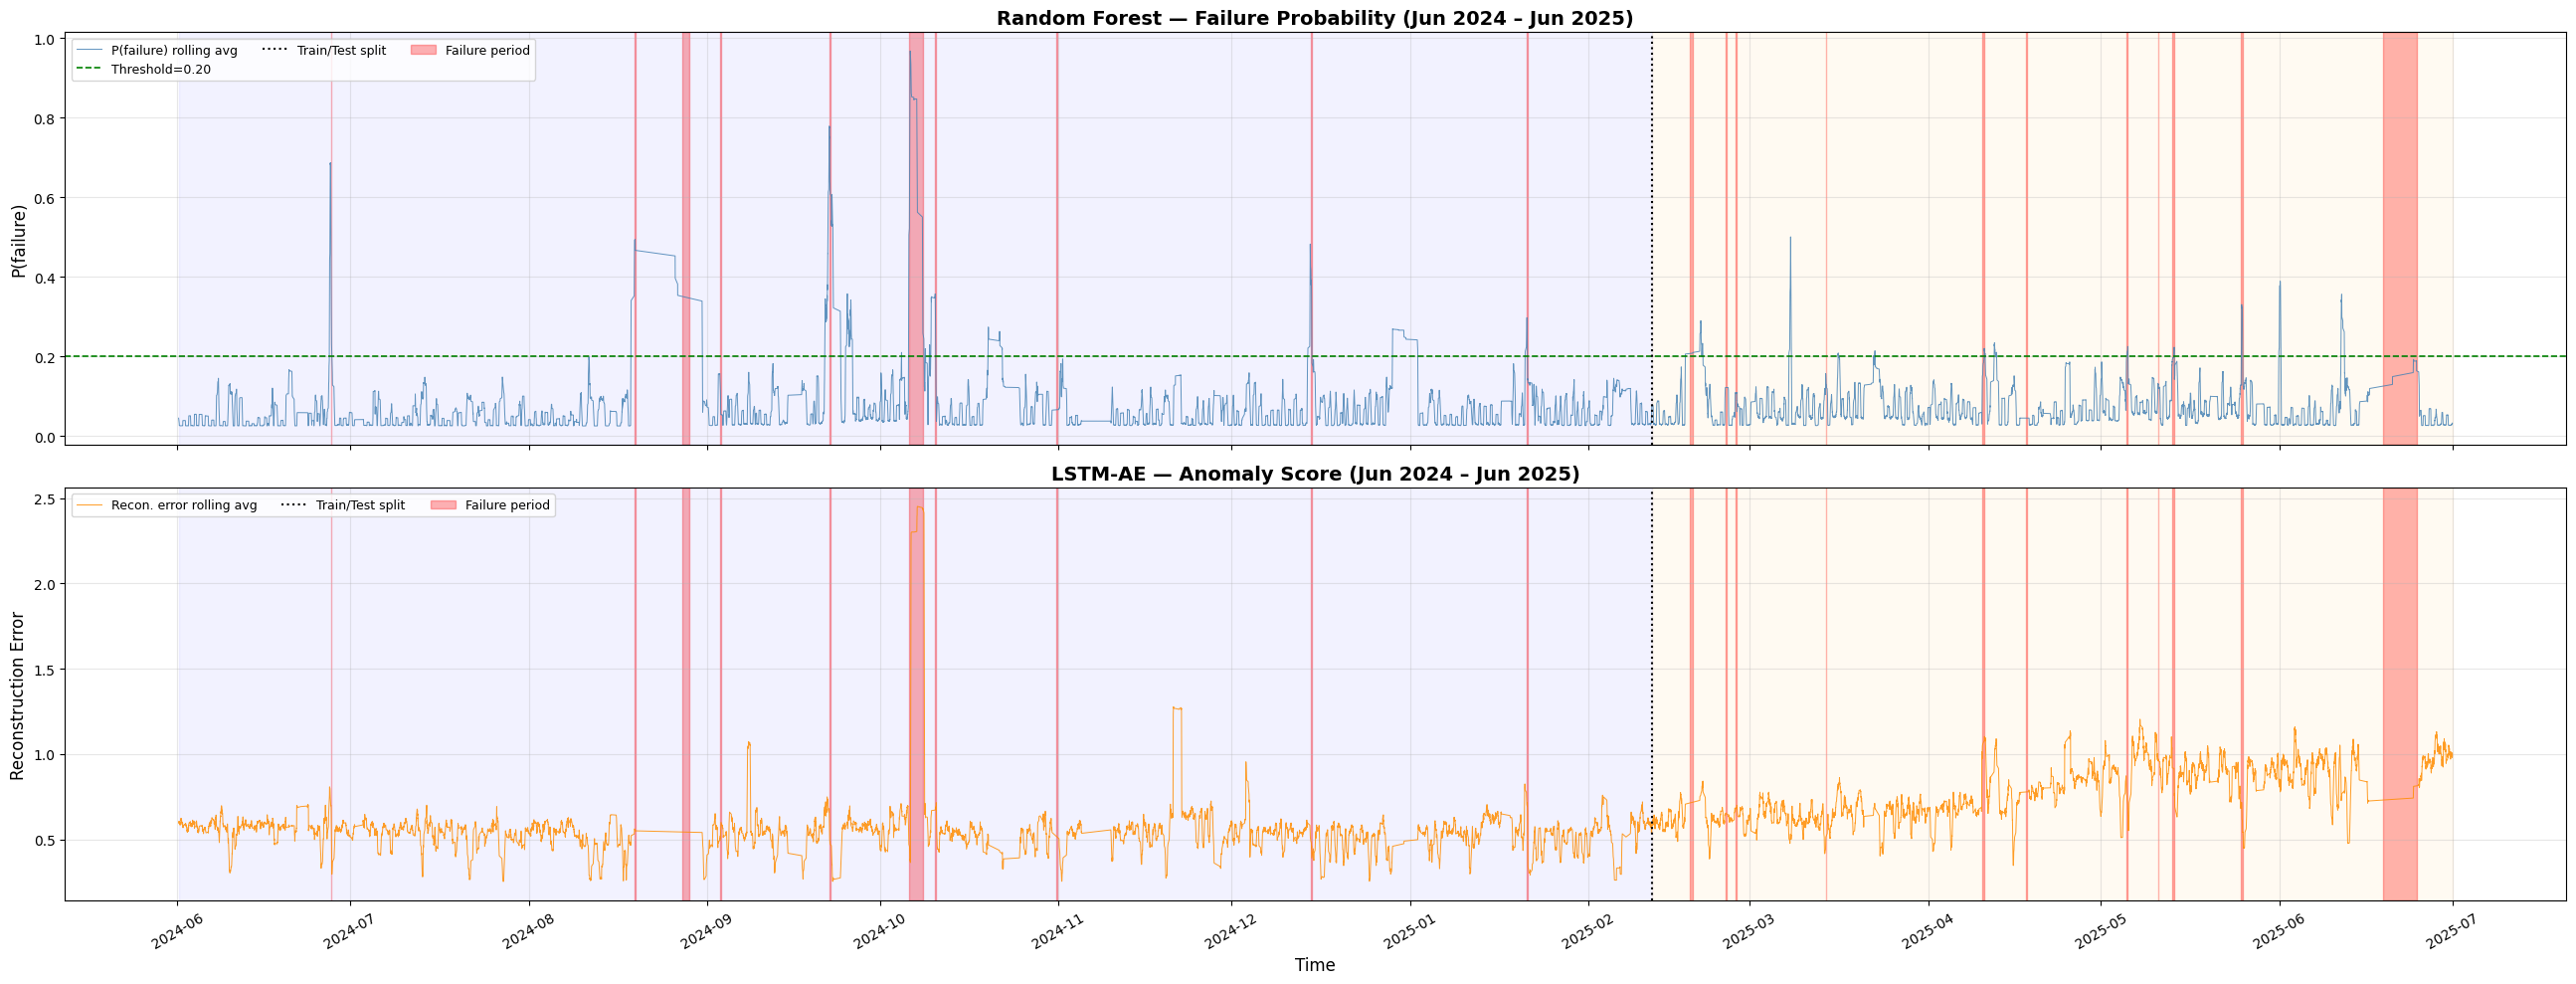

Saved anomaly_timeline_full.png


In [5]:
# Rolling averages
rf_all_ts = rf_all.set_index('window_end').sort_index()
ae_all_ts = ae_all.set_index('window_end').sort_index()

rf_roll = rf_all_ts['prob'].rolling(50, center=True, min_periods=1).mean()
ae_roll = ae_all_ts['score'].rolling(20, center=True, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(26, 10), sharex=True)

# RF panel
ax = axes[0]
ax.plot(rf_roll.index, rf_roll.values, color='steelblue', linewidth=0.7, alpha=0.85, label='P(failure) rolling avg')
ax.axhline(y=RF_THR, color='green', linestyle='--', linewidth=1.2, label=f'Threshold={RF_THR:.2f}')
ax.axvline(x=SPLIT_DATE, color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
for i, (_, ev) in enumerate(fail_events_all.iterrows()):
    ax.axvspan(ev['start'], ev['end'], alpha=0.3, color='red', label='Failure period' if i == 0 else '_')
ax.axvspan(rf_all_ts.index.min(), SPLIT_DATE, alpha=0.05, color='blue')
ax.axvspan(SPLIT_DATE, rf_all_ts.index.max(), alpha=0.05, color='orange')
ax.set_ylabel('P(failure)', fontsize=12)
ax.set_title('Random Forest — Failure Probability (Jun 2024 – Jun 2025)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)

# LSTM-AE panel
ax = axes[1]
ax.plot(ae_roll.index, ae_roll.values, color='darkorange', linewidth=0.7, alpha=0.85, label='Recon. error rolling avg')
ax.axvline(x=SPLIT_DATE, color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
for i, (_, ev) in enumerate(fail_events_all.iterrows()):
    ax.axvspan(ev['start'], ev['end'], alpha=0.3, color='red', label='Failure period' if i == 0 else '_')
ax.axvspan(ae_all_ts.index.min(), SPLIT_DATE, alpha=0.05, color='blue')
ax.axvspan(SPLIT_DATE, ae_all_ts.index.max(), alpha=0.05, color='orange')
ax.set_ylabel('Reconstruction Error', fontsize=12)
ax.set_title('LSTM-AE — Anomaly Score (Jun 2024 – Jun 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.legend(loc='upper left', fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'anomaly_timeline_full.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved anomaly_timeline_full.png')

## 3. Score Distributions — Train vs Test, by Month

How do anomaly scores differ between train and test? Do they shift over time (concept drift)?

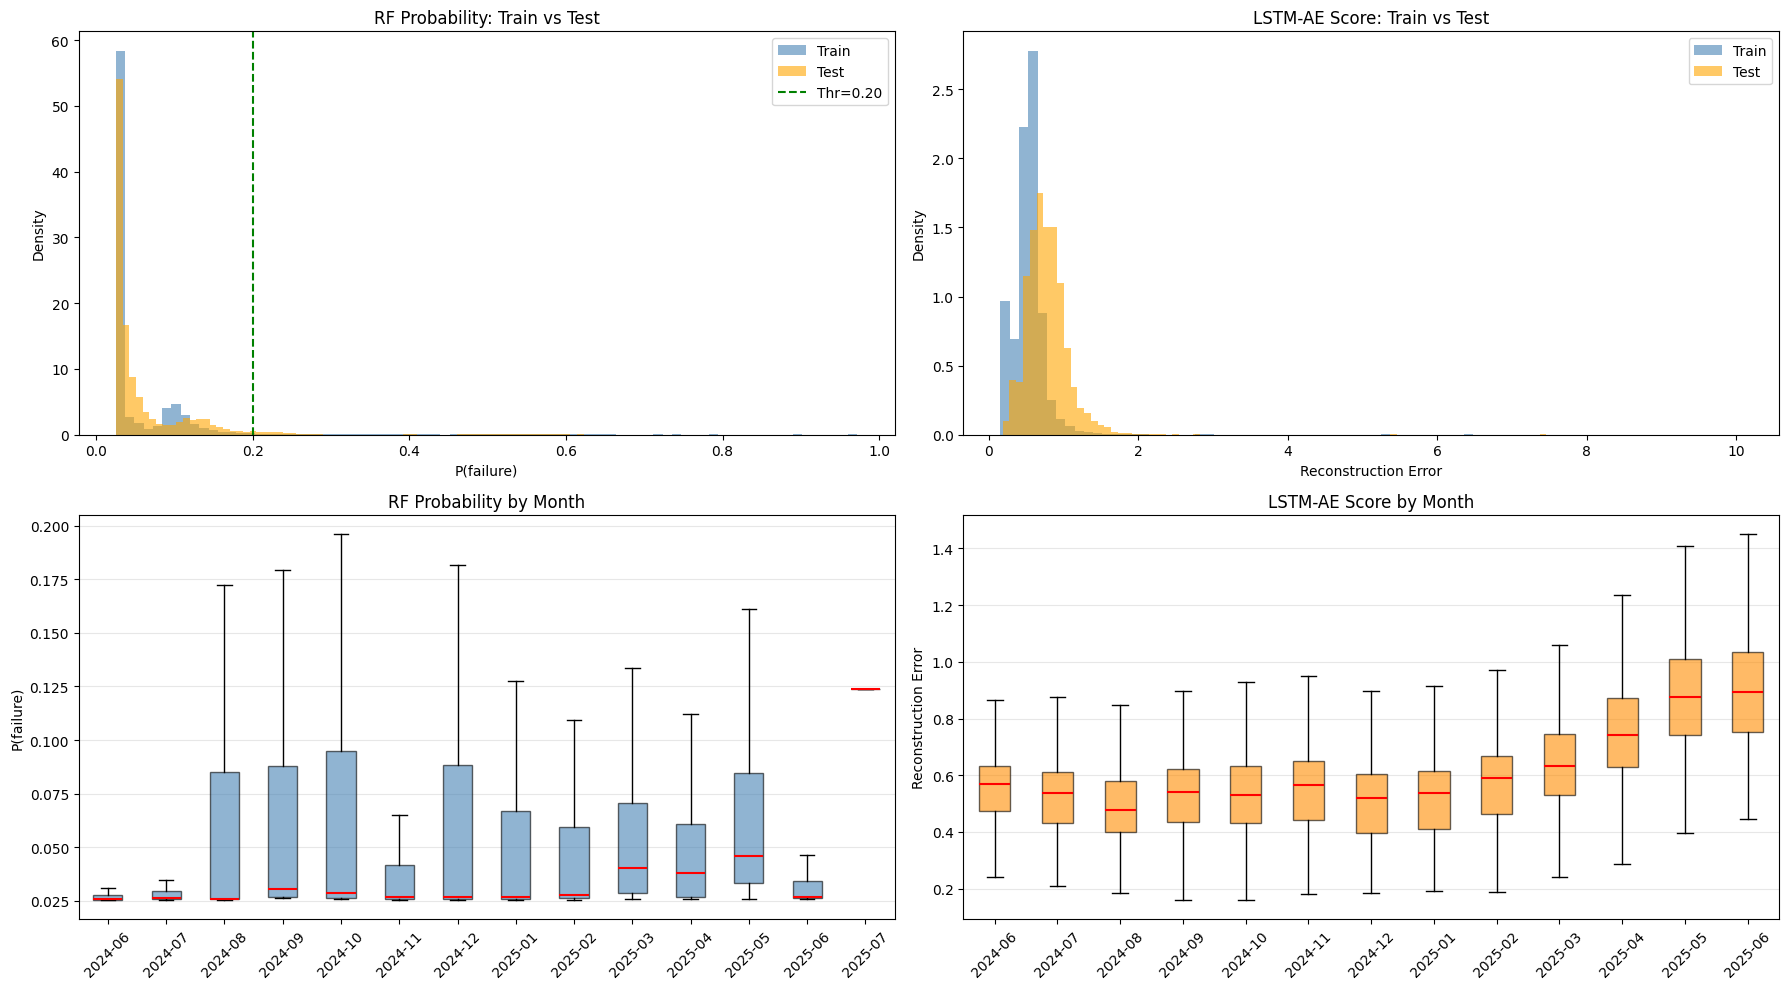


RF probability stats:
  train: mean=0.0614, median=0.0268, std=0.0958, above_thr=1421 (3.43%)
  test: mean=0.0641, median=0.0366, std=0.0738, above_thr=879 (3.80%)

LSTM-AE score stats:
  train: mean=0.5388, median=0.5383, std=0.2598, p95=0.8257, p99=1.1794
  test: mean=0.7742, median=0.7459, std=0.2834, p95=1.2276, p99=1.5794


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 3a. RF probability: train vs test
ax = axes[0, 0]
ax.hist(rf_all.loc[rf_all['split']=='train', 'prob'], bins=80, alpha=0.6, color='steelblue', label='Train', density=True)
ax.hist(rf_all.loc[rf_all['split']=='test', 'prob'], bins=80, alpha=0.6, color='orange', label='Test', density=True)
ax.axvline(RF_THR, color='green', linestyle='--', label=f'Thr={RF_THR:.2f}')
ax.set_xlabel('P(failure)')
ax.set_ylabel('Density')
ax.set_title('RF Probability: Train vs Test')
ax.legend()

# 3b. LSTM-AE score: train vs test
ax = axes[0, 1]
ax.hist(ae_all.loc[ae_all['split']=='train', 'score'], bins=80, alpha=0.6, color='steelblue', label='Train', density=True)
ax.hist(ae_all.loc[ae_all['split']=='test', 'score'], bins=80, alpha=0.6, color='orange', label='Test', density=True)
ax.set_xlabel('Reconstruction Error')
ax.set_ylabel('Density')
ax.set_title('LSTM-AE Score: Train vs Test')
ax.legend()

# 3c. RF monthly boxplot
ax = axes[1, 0]
rf_all['month'] = rf_all['window_end'].dt.to_period('M').astype(str)
months = sorted(rf_all['month'].unique())
data_by_month = [rf_all.loc[rf_all['month']==m, 'prob'].values for m in months]
bp = ax.boxplot(data_by_month, labels=months, patch_artist=True, showfliers=False,
                medianprops=dict(color='red', linewidth=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_ylabel('P(failure)')
ax.set_title('RF Probability by Month')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# 3d. LSTM-AE monthly boxplot
ax = axes[1, 1]
ae_all['month'] = ae_all['window_end'].dt.to_period('M').astype(str)
ae_months = sorted(ae_all['month'].unique())
ae_data_by_month = [ae_all.loc[ae_all['month']==m, 'score'].values for m in ae_months]
bp = ax.boxplot(ae_data_by_month, labels=ae_months, patch_artist=True, showfliers=False,
                medianprops=dict(color='red', linewidth=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('darkorange')
    patch.set_alpha(0.6)
ax.set_ylabel('Reconstruction Error')
ax.set_title('LSTM-AE Score by Month')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Stats
print('\nRF probability stats:')
for split in ['train', 'test']:
    s = rf_all.loc[rf_all['split']==split, 'prob']
    above = (s >= RF_THR).sum()
    print(f'  {split}: mean={s.mean():.4f}, median={s.median():.4f}, '
          f'std={s.std():.4f}, above_thr={above} ({100*above/len(s):.2f}%)')

print('\nLSTM-AE score stats:')
for split in ['train', 'test']:
    s = ae_all.loc[ae_all['split']==split, 'score']
    print(f'  {split}: mean={s.mean():.4f}, median={s.median():.4f}, '
          f'std={s.std():.4f}, p95={s.quantile(0.95):.4f}, p99={s.quantile(0.99):.4f}')

## 4. Anomaly Hotspot Detection

Find sustained high-score periods — clusters of consecutive windows where anomaly scores stay elevated, regardless of failure labels. These represent "interesting" periods the models flag.

In [7]:
# ── RF hotspots: consecutive windows above threshold ──
rf_sorted = rf_all.sort_values('window_end').reset_index(drop=True)
above = (rf_sorted['prob'] >= RF_THR).astype(int)
grp = (above != above.shift()).cumsum()
hotspots_rf = []
for g, sub in rf_sorted[above == 1].groupby(grp[above == 1]):
    if len(sub) >= 3:  # at least 3 consecutive windows
        hotspots_rf.append({
            'start': sub['window_end'].min(),
            'end': sub['window_end'].max(),
            'n_windows': len(sub),
            'mean_prob': sub['prob'].mean(),
            'max_prob': sub['prob'].max(),
            'n_failure': sub['fail'].sum(),
            'split': sub['split'].iloc[0],
        })
hotspots_rf = pd.DataFrame(hotspots_rf)
hotspots_rf['duration_min'] = (hotspots_rf['end'] - hotspots_rf['start']).dt.total_seconds() / 60
hotspots_rf['has_failure'] = hotspots_rf['n_failure'] > 0

# ── LSTM-AE hotspots: above 90th percentile ──
ae_p90 = ae_all['score'].quantile(0.90)
ae_sorted = ae_all.sort_values('window_end').reset_index(drop=True)
ae_above = (ae_sorted['score'] >= ae_p90).astype(int)
ae_grp = (ae_above != ae_above.shift()).cumsum()
hotspots_ae = []
for g, sub in ae_sorted[ae_above == 1].groupby(ae_grp[ae_above == 1]):
    if len(sub) >= 2:  # at least 2 consecutive sequences
        hotspots_ae.append({
            'start': sub['window_end'].min(),
            'end': sub['window_end'].max(),
            'n_seqs': len(sub),
            'mean_score': sub['score'].mean(),
            'max_score': sub['score'].max(),
            'n_failure': sub['fail'].sum(),
            'split': sub['split'].iloc[0],
        })
hotspots_ae = pd.DataFrame(hotspots_ae)
if len(hotspots_ae) > 0:
    hotspots_ae['duration_min'] = (hotspots_ae['end'] - hotspots_ae['start']).dt.total_seconds() / 60
    hotspots_ae['has_failure'] = hotspots_ae['n_failure'] > 0

print(f'RF hotspots (>=3 consecutive windows above thr={RF_THR:.2f}): {len(hotspots_rf)}')
print(f'  With actual failure: {hotspots_rf["has_failure"].sum()} | Without (potential false alarm clusters): {(~hotspots_rf["has_failure"]).sum()}')
print(f'  Train: {(hotspots_rf["split"]=="train").sum()} | Test: {(hotspots_rf["split"]=="test").sum()}')
print(f'\nLSTM-AE hotspots (>=2 consecutive seqs above p90={ae_p90:.3f}): {len(hotspots_ae)}')
if len(hotspots_ae) > 0:
    print(f'  With actual failure: {hotspots_ae["has_failure"].sum()} | Without: {(~hotspots_ae["has_failure"]).sum()}')

print(f'\n--- Top 15 RF hotspots by duration ---')
top_hs = hotspots_rf.nlargest(15, 'n_windows')[['start', 'end', 'n_windows', 'duration_min', 'mean_prob', 'n_failure', 'has_failure', 'split']]
print(top_hs.to_string(index=False))

RF hotspots (>=3 consecutive windows above thr=0.20): 186
  With actual failure: 27 | Without (potential false alarm clusters): 159
  Train: 124 | Test: 62

LSTM-AE hotspots (>=2 consecutive seqs above p90=0.928): 278
  With actual failure: 6 | Without: 272

--- Top 15 RF hotspots by duration ---
              start                 end  n_windows  duration_min  mean_prob  n_failure  has_failure split
2024-10-06 00:02:30 2024-10-08 10:22:30        147   3500.000000   0.801193        135         True train
2024-09-22 13:04:10 2024-09-24 02:06:40         88   2222.500000   0.561663          0        False train
2024-09-21 22:00:00 2024-09-22 07:20:00         75    560.000000   0.704683         58         True train
2024-06-27 15:27:30 2024-06-27 20:19:10         51    291.666667   0.234179         25         True train
2025-03-07 23:09:10 2025-03-08 04:35:50         49    326.666667   0.509349          0        False  test
2025-02-20 16:25:50 2025-02-20 21:00:00         48    274.166667  

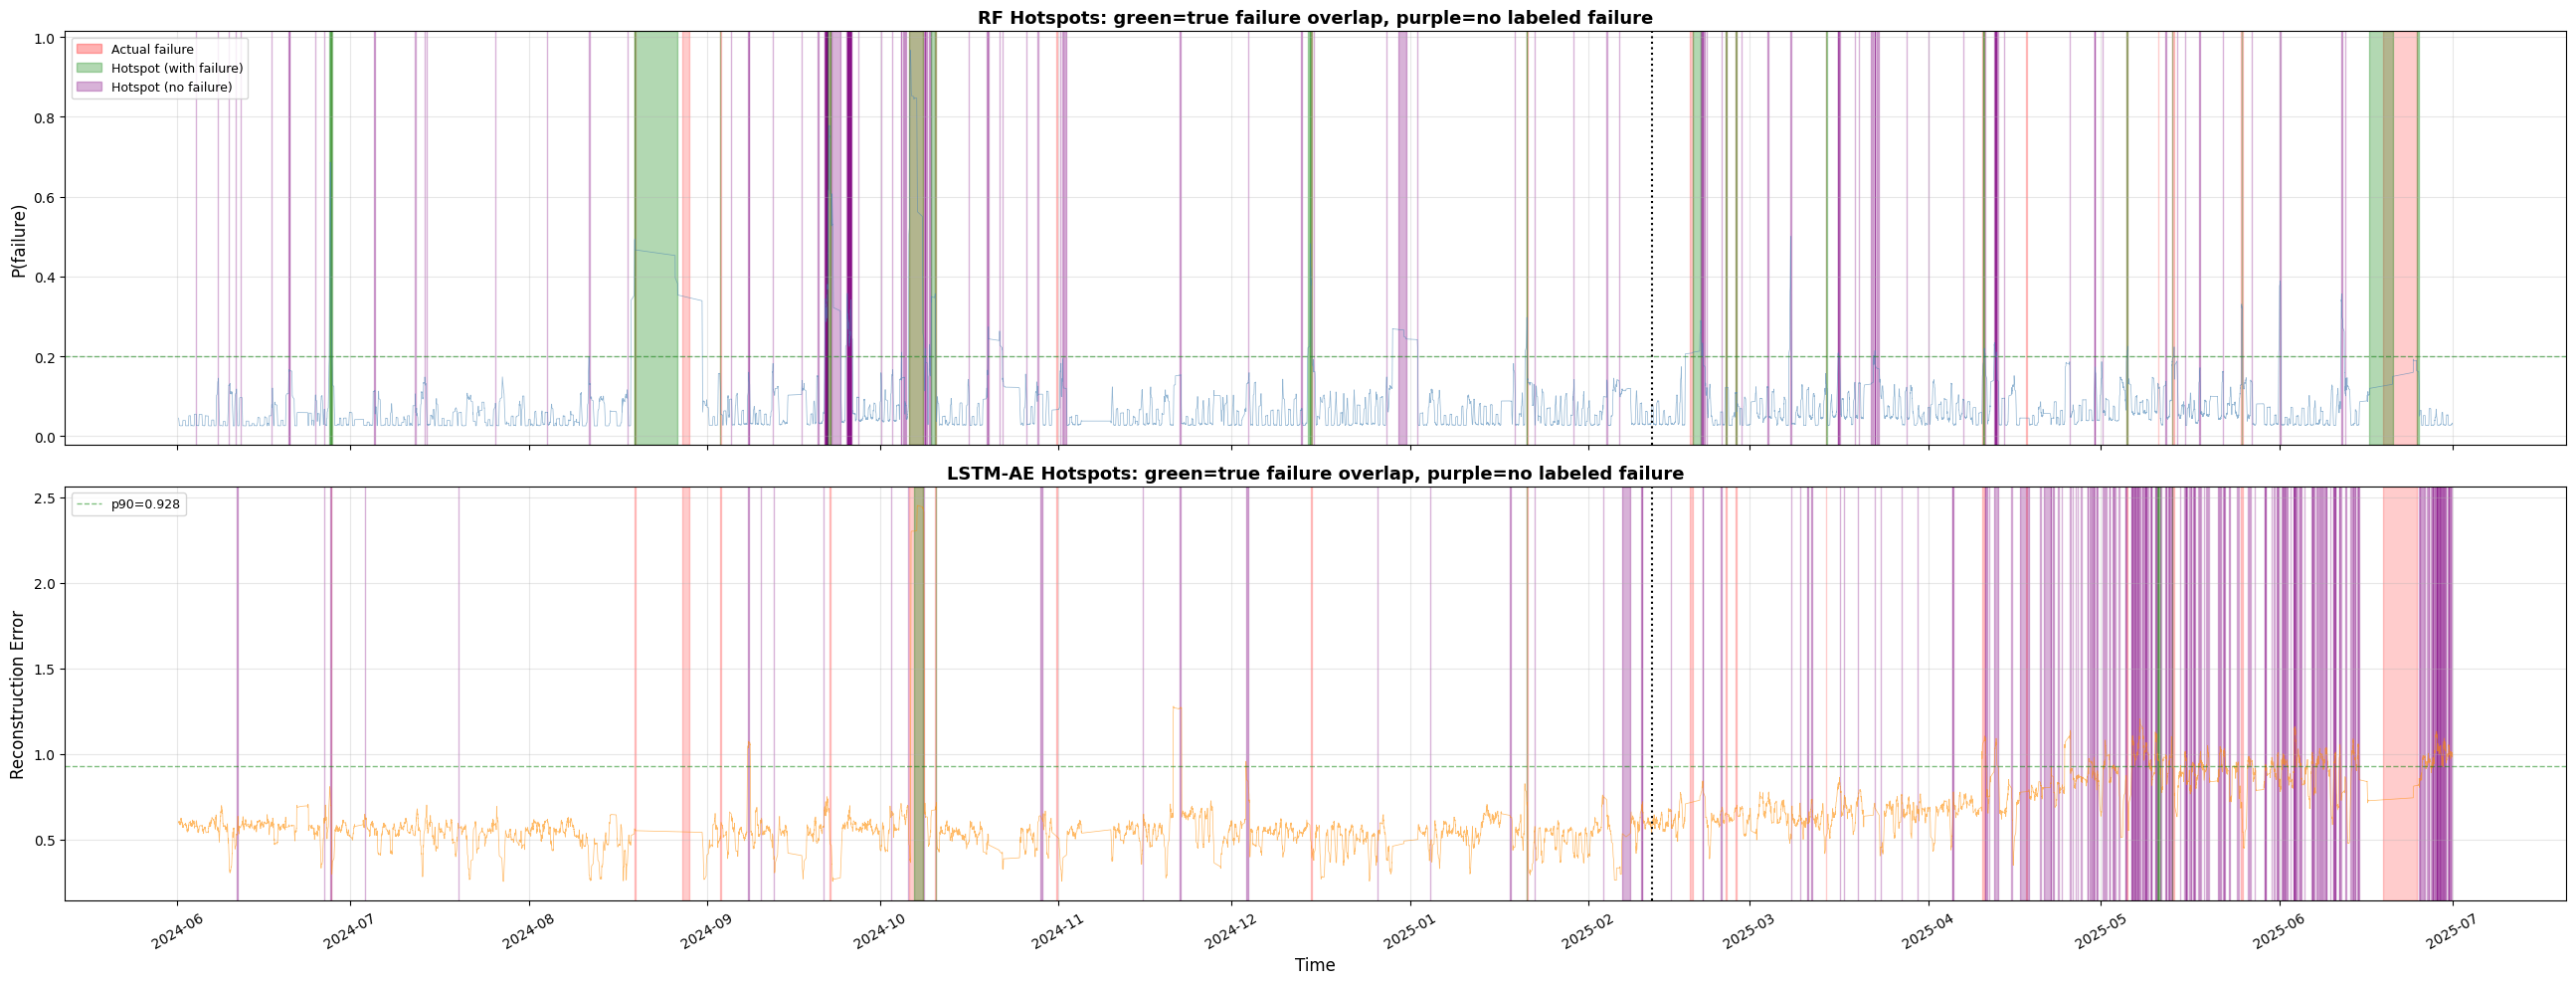

In [8]:
# ── Visualize hotspots on timeline ──
fig, axes = plt.subplots(2, 1, figsize=(26, 10), sharex=True)

# RF
ax = axes[0]
ax.plot(rf_roll.index, rf_roll.values, color='steelblue', linewidth=0.5, alpha=0.6)
ax.axhline(y=RF_THR, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=SPLIT_DATE, color='black', linestyle=':', linewidth=1.5)
for _, ev in fail_events_all.iterrows():
    ax.axvspan(ev['start'], ev['end'], alpha=0.2, color='red')
# Highlight hotspots
for _, hs in hotspots_rf.iterrows():
    color = 'green' if hs['has_failure'] else 'purple'
    ax.axvspan(hs['start'], hs['end'], alpha=0.3, color=color)
ax.set_ylabel('P(failure)', fontsize=12)
ax.set_title('RF Hotspots: green=true failure overlap, purple=no labeled failure', fontsize=13, fontweight='bold')
ax.legend(handles=[
    Patch(color='red', alpha=0.3, label='Actual failure'),
    Patch(color='green', alpha=0.3, label='Hotspot (with failure)'),
    Patch(color='purple', alpha=0.3, label='Hotspot (no failure)'),
], loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# LSTM-AE
ax = axes[1]
ax.plot(ae_roll.index, ae_roll.values, color='darkorange', linewidth=0.5, alpha=0.6)
ax.axhline(y=ae_p90, color='green', linestyle='--', linewidth=1, alpha=0.5, label=f'p90={ae_p90:.3f}')
ax.axvline(x=SPLIT_DATE, color='black', linestyle=':', linewidth=1.5)
for _, ev in fail_events_all.iterrows():
    ax.axvspan(ev['start'], ev['end'], alpha=0.2, color='red')
if len(hotspots_ae) > 0:
    for _, hs in hotspots_ae.iterrows():
        color = 'green' if hs['has_failure'] else 'purple'
        ax.axvspan(hs['start'], hs['end'], alpha=0.3, color=color)
ax.set_ylabel('Reconstruction Error', fontsize=12)
ax.set_title('LSTM-AE Hotspots: green=true failure overlap, purple=no labeled failure', fontsize=13, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30, fontsize=10)
plt.tight_layout()
plt.show()

## 5. Subsystem-Level Feature Discriminability

For each feature, compute Cohen's d (effect size) between normal and failure windows. Group by subsystem to see which subsystems are most discriminative.

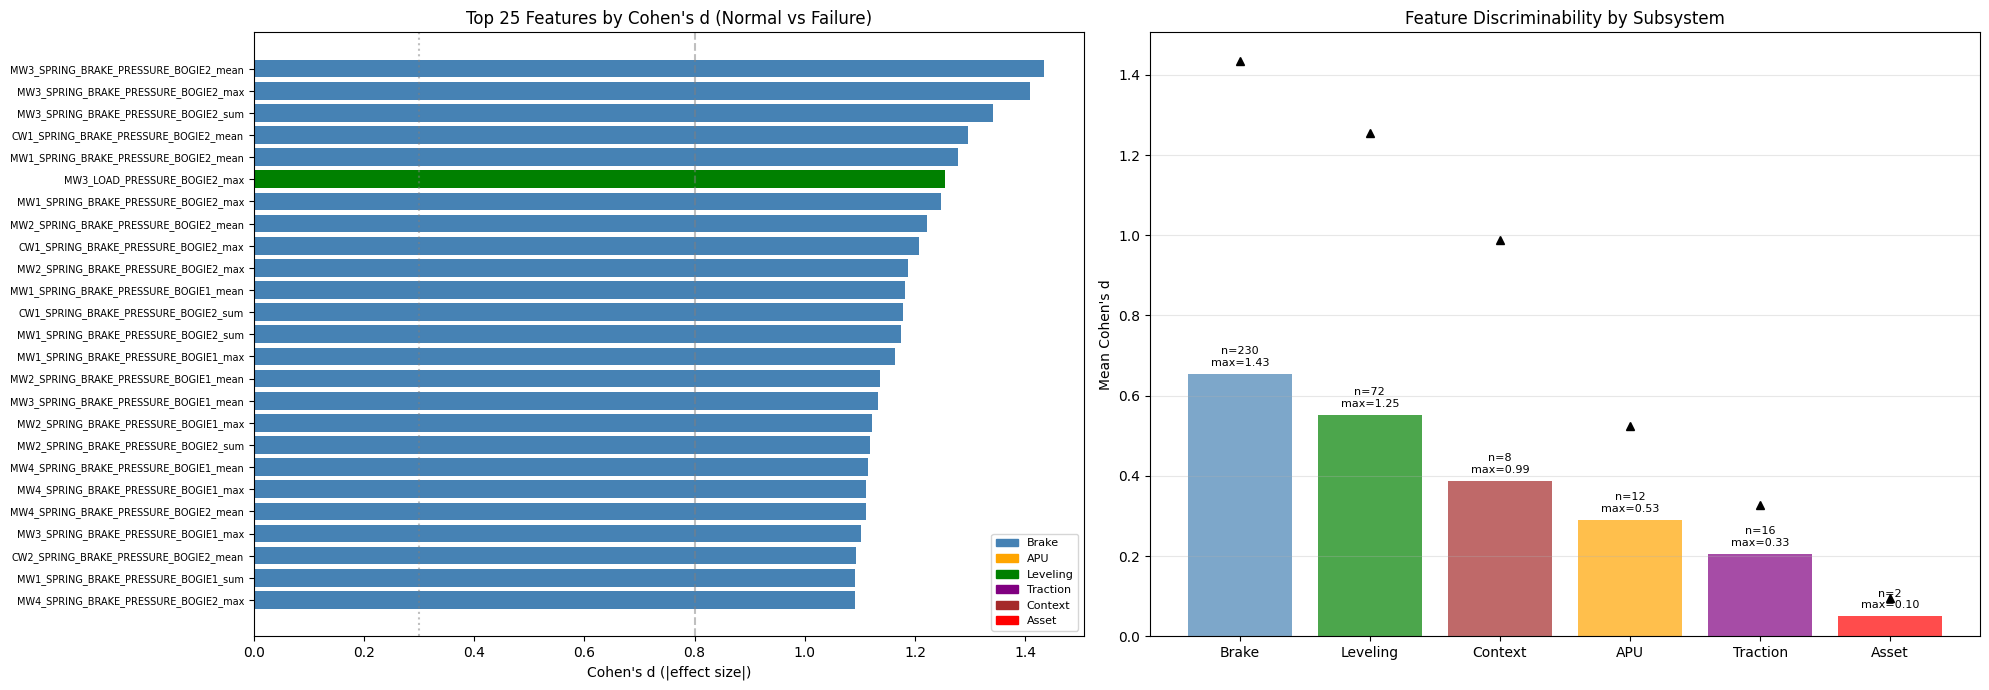

Features with Cohen's d > 0.3 (at least small effect):
  Total: 268 / 340
  Brake: 206/230 features
  Leveling: 51/72 features
  Context: 3/8 features
  APU: 5/12 features
  Traction: 3/16 features

Subsystem mean Cohen's d:
               mean    median       max  count
subsystem                                     
Brake      0.654723  0.669667  1.434404    230
Leveling   0.551521  0.595738  1.254161     72
Context    0.387884  0.103590  0.988100      8
APU        0.290318  0.254673  0.525333     12
Traction   0.205347  0.225389  0.327563     16
Asset      0.049763  0.049763  0.095431      2


In [9]:
# Subsystem mapping
def get_subsystem(name):
    name_upper = name.upper()
    if 'DAYS_SINCE' in name_upper:
        return 'Asset'
    if 'MAIN_RESERVOIR' in name_upper or 'COMPRESSOR' in name_upper:
        return 'APU'
    if 'LOAD_PRESSURE' in name_upper or 'LOAD_SIGNAL' in name_upper:
        return 'Leveling'
    if 'ENERGY_BRAKING' in name_upper:
        return 'Traction'
    if 'SPEED' in name_upper or 'TEMPERATURE' in name_upper:
        return 'Context'
    return 'Brake'

# Cohen's d for each feature
normal = rf_feats_all[rf_feats_all['label'] == 0]
failure = rf_feats_all[rf_feats_all['label'] == 1]

cohens_d = []
for col in feature_cols:
    n_vals = normal[col].dropna()
    f_vals = failure[col].dropna()
    if len(n_vals) < 10 or len(f_vals) < 10 or n_vals.std() == 0:
        d = 0.0
    else:
        pooled_std = np.sqrt((n_vals.var() * (len(n_vals)-1) + f_vals.var() * (len(f_vals)-1)) / 
                            (len(n_vals) + len(f_vals) - 2))
        d = abs(f_vals.mean() - n_vals.mean()) / pooled_std if pooled_std > 0 else 0.0
    cohens_d.append({'feature': col, 'cohens_d': d, 'subsystem': get_subsystem(col)})

cd_df = pd.DataFrame(cohens_d).sort_values('cohens_d', ascending=False).reset_index(drop=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Top 25 features by Cohen's d
ax = axes[0]
top25 = cd_df.head(25)
colors_map = {'Brake': 'steelblue', 'APU': 'orange', 'Leveling': 'green', 
              'Traction': 'purple', 'Context': 'brown', 'Asset': 'red'}
ax.barh(range(len(top25)), top25['cohens_d'].values,
        color=[colors_map.get(s, 'gray') for s in top25['subsystem']])
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25['feature'].values, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Cohen's d (|effect size|)")
ax.set_title('Top 25 Features by Cohen\'s d (Normal vs Failure)')
ax.axvline(0.3, color='gray', linestyle=':', alpha=0.5, label='small effect (0.3)')
ax.axvline(0.8, color='gray', linestyle='--', alpha=0.5, label='large effect (0.8)')
legend_patches = [Patch(color=c, label=s) for s, c in colors_map.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

# Cohen's d by subsystem
ax = axes[1]
sub_cd = cd_df.groupby('subsystem')['cohens_d'].agg(['mean', 'median', 'max', 'count'])
sub_cd = sub_cd.sort_values('mean', ascending=False)
x = list(range(len(sub_cd)))
ax.bar(x, sub_cd['mean'], color=[colors_map.get(s, 'gray') for s in sub_cd.index], alpha=0.7)
for i, (idx, row) in enumerate(sub_cd.iterrows()):
    ax.plot(i, row['max'], 'k^', markersize=6)
    ax.text(i, row['mean'] + 0.02, f'n={int(row["count"])}\nmax={row["max"]:.2f}', 
            ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(sub_cd.index)
ax.set_ylabel("Mean Cohen's d")
ax.set_title('Feature Discriminability by Subsystem')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary
print('Features with Cohen\'s d > 0.3 (at least small effect):')
sig = cd_df[cd_df['cohens_d'] > 0.3]
print(f'  Total: {len(sig)} / {len(cd_df)}')
for sub in sig['subsystem'].unique():
    n = (sig['subsystem'] == sub).sum()
    total = (cd_df['subsystem'] == sub).sum()
    print(f'  {sub}: {n}/{total} features')

print(f'\nSubsystem mean Cohen\'s d:')
print(sub_cd[['mean', 'median', 'max', 'count']].to_string())

## 6. Within-Subsystem Correlation Analysis

Do sensors within the same subsystem correlate more strongly? Does this correlation break down during failure periods?

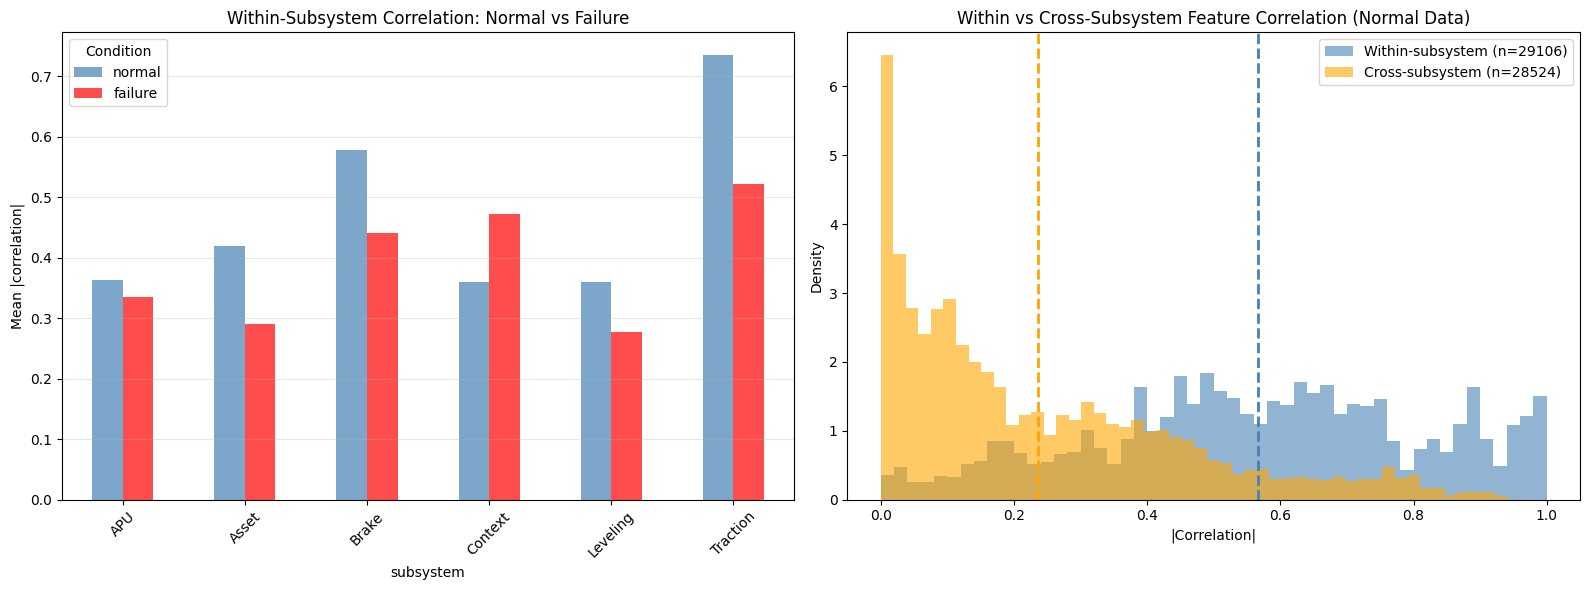

Within-subsystem mean |corr|: 0.567
Cross-subsystem mean |corr|: 0.236
Ratio: 2.4x

Within-subsystem correlation (normal vs failure):
condition    normal   failure
subsystem                    
APU        0.363527  0.334641
Asset      0.419880  0.289946
Brake      0.578756  0.441256
Context    0.360672  0.472615
Leveling   0.360275  0.278004
Traction   0.735800  0.521489


In [10]:
# Group features by subsystem
subsystem_feats = {}
for col in feature_cols:
    sub = get_subsystem(col)
    subsystem_feats.setdefault(sub, []).append(col)

# Compute within-subsystem correlation for normal vs failure
corr_results = []
for sub, feats in subsystem_feats.items():
    if len(feats) < 2:
        continue
    for condition, data in [('normal', normal), ('failure', failure)]:
        corr_mat = data[feats].corr().abs()
        # Upper triangle only (exclude diagonal)
        mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
        mean_corr = corr_mat.where(mask).stack().mean()
        corr_results.append({
            'subsystem': sub, 'condition': condition, 
            'mean_within_corr': mean_corr, 'n_features': len(feats)
        })

corr_df = pd.DataFrame(corr_results)

# Cross-subsystem correlation (sample to keep it fast)
sample_n = min(5000, len(normal))
normal_sample = normal[feature_cols].sample(sample_n, random_state=42)
full_corr = normal_sample.corr().abs()

within_vals, cross_vals = [], []
for i, c1 in enumerate(feature_cols):
    for j, c2 in enumerate(feature_cols):
        if j <= i:
            continue
        val = full_corr.loc[c1, c2]
        if get_subsystem(c1) == get_subsystem(c2):
            within_vals.append(val)
        else:
            cross_vals.append(val)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Within-subsystem correlation: normal vs failure
ax = axes[0]
pivot = corr_df.pivot(index='subsystem', columns='condition', values='mean_within_corr')
pivot = pivot.reindex(columns=['normal', 'failure'])
pivot.plot(kind='bar', ax=ax, color=['steelblue', 'red'], alpha=0.7)
ax.set_ylabel('Mean |correlation|')
ax.set_title('Within-Subsystem Correlation: Normal vs Failure')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(title='Condition')

# Within vs cross-subsystem
ax = axes[1]
ax.hist(within_vals, bins=50, alpha=0.6, color='steelblue', label=f'Within-subsystem (n={len(within_vals)})', density=True)
ax.hist(cross_vals, bins=50, alpha=0.6, color='orange', label=f'Cross-subsystem (n={len(cross_vals)})', density=True)
ax.axvline(np.mean(within_vals), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(np.mean(cross_vals), color='orange', linestyle='--', linewidth=2)
ax.set_xlabel('|Correlation|')
ax.set_ylabel('Density')
ax.set_title('Within vs Cross-Subsystem Feature Correlation (Normal Data)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Within-subsystem mean |corr|: {np.mean(within_vals):.3f}')
print(f'Cross-subsystem mean |corr|: {np.mean(cross_vals):.3f}')
print(f'Ratio: {np.mean(within_vals)/np.mean(cross_vals):.1f}x')
print(f'\nWithin-subsystem correlation (normal vs failure):')
print(pivot.to_string())

## 7. Unsupervised Data: Standardization & Channel Checks

Verify z-score normalization quality and identify near-constant channels.

Near-constant channels (std < 0.01): 0


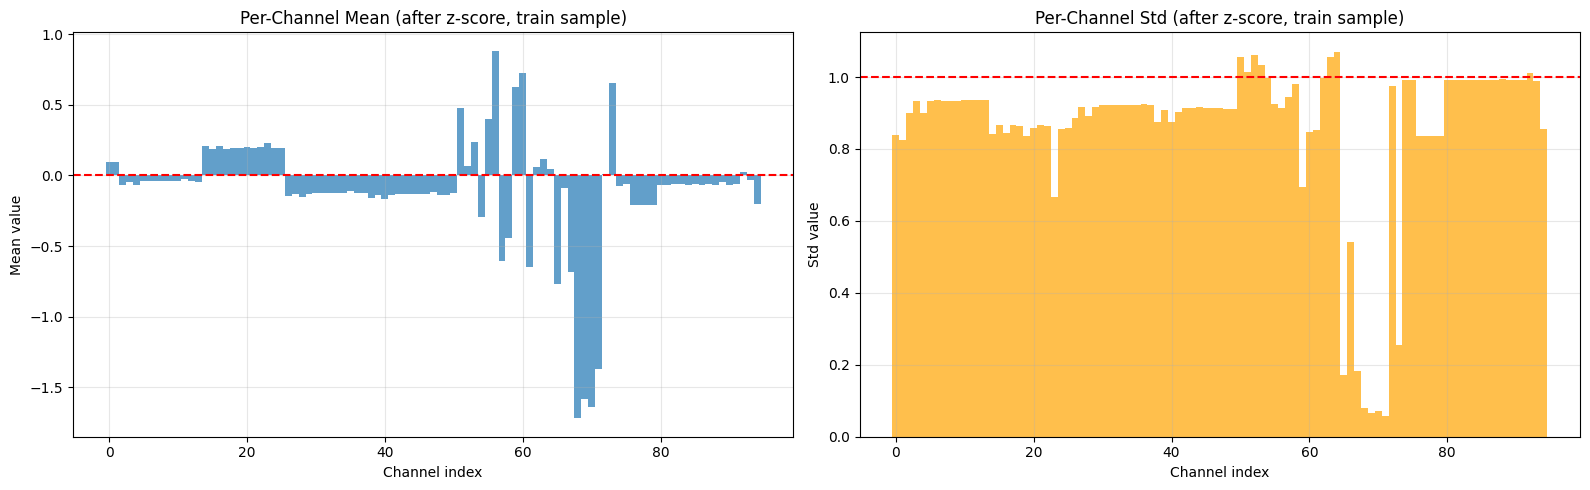


Channel mean: overall mean=-0.0921, std of means=0.4003
Channel std: overall mean=0.8600, std of stds=0.2218
Channels with |mean| > 0.5: [('MW2_LOAD_PRESSURE_BOGIE1', '0.884'), ('MW2_LOAD_PRESSURE_BOGIE2', '-0.602'), ('MW3_LOAD_PRESSURE_BOGIE2', '0.629'), ('MW4_LOAD_PRESSURE_BOGIE1', '0.723'), ('MW4_LOAD_PRESSURE_BOGIE2', '-0.652'), ('MW2_LOAD_SIGNAL', '-0.769'), ('MW4_LOAD_SIGNAL', '-0.683'), ('MW1_ENERGY_BRAKING_RESISTANCE', '-1.720'), ('MW2_ENERGY_BRAKING_RESISTANCE', '-1.586'), ('MW3_ENERGY_BRAKING_RESISTANCE', '-1.642'), ('MW4_ENERGY_BRAKING_RESISTANCE', '-1.373'), ('AMBIENT_TEMPERATURE', '0.656')]


In [11]:
# Load metadata
with open(os.path.join(OUT_DIR, 'unsupervised', 'metadata.json')) as f:
    meta = json.load(f)
UNSUP_CHANNELS = meta['channels']
channel_stats = meta['channel_stats']

# Check channel statistics
ch_info = pd.DataFrame([
    {'channel': ch, 'mean': channel_stats[ch]['mean'], 'std': channel_stats[ch]['std'],
     'subsystem': get_subsystem(ch)}
    for ch in UNSUP_CHANNELS
])

# Near-constant channels (very low std)
low_var = ch_info[ch_info['std'] < 0.01].sort_values('std')
print(f'Near-constant channels (std < 0.01): {len(low_var)}')
if len(low_var) > 0:
    print(low_var[['channel', 'mean', 'std', 'subsystem']].to_string(index=False))

# Load a small sample of train sequences to verify standardization
train_seqs = np.load(os.path.join(OUT_DIR, 'unsupervised', 'train.npy'), mmap_mode='r')
sample = train_seqs[:500]  # first 500 sequences

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-channel mean across sample
ax = axes[0]
ch_means = sample.mean(axis=(0, 1))  # mean over sequences and timesteps
ch_stds = sample.std(axis=(0, 1))
ax.bar(range(len(ch_means)), ch_means, alpha=0.7, width=1.0)
ax.set_xlabel('Channel index')
ax.set_ylabel('Mean value')
ax.set_title('Per-Channel Mean (after z-score, train sample)')
ax.axhline(0, color='red', linestyle='--')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(range(len(ch_stds)), ch_stds, alpha=0.7, width=1.0, color='orange')
ax.set_xlabel('Channel index')
ax.set_ylabel('Std value')
ax.set_title('Per-Channel Std (after z-score, train sample)')
ax.axhline(1, color='red', linestyle='--')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

del train_seqs, sample; gc.collect()

# Summary
print(f'\nChannel mean: overall mean={ch_means.mean():.4f}, std of means={ch_means.std():.4f}')
print(f'Channel std: overall mean={ch_stds.mean():.4f}, std of stds={ch_stds.std():.4f}')
outlier_ch = np.where(np.abs(ch_means) > 0.5)[0]
if len(outlier_ch) > 0:
    print(f'Channels with |mean| > 0.5: {[(UNSUP_CHANNELS[i], f"{ch_means[i]:.3f}") for i in outlier_ch]}')

## 8. Temporal Coverage & Operational Patterns

How many windows per day? Are there gaps? How do scores relate to time-of-day?

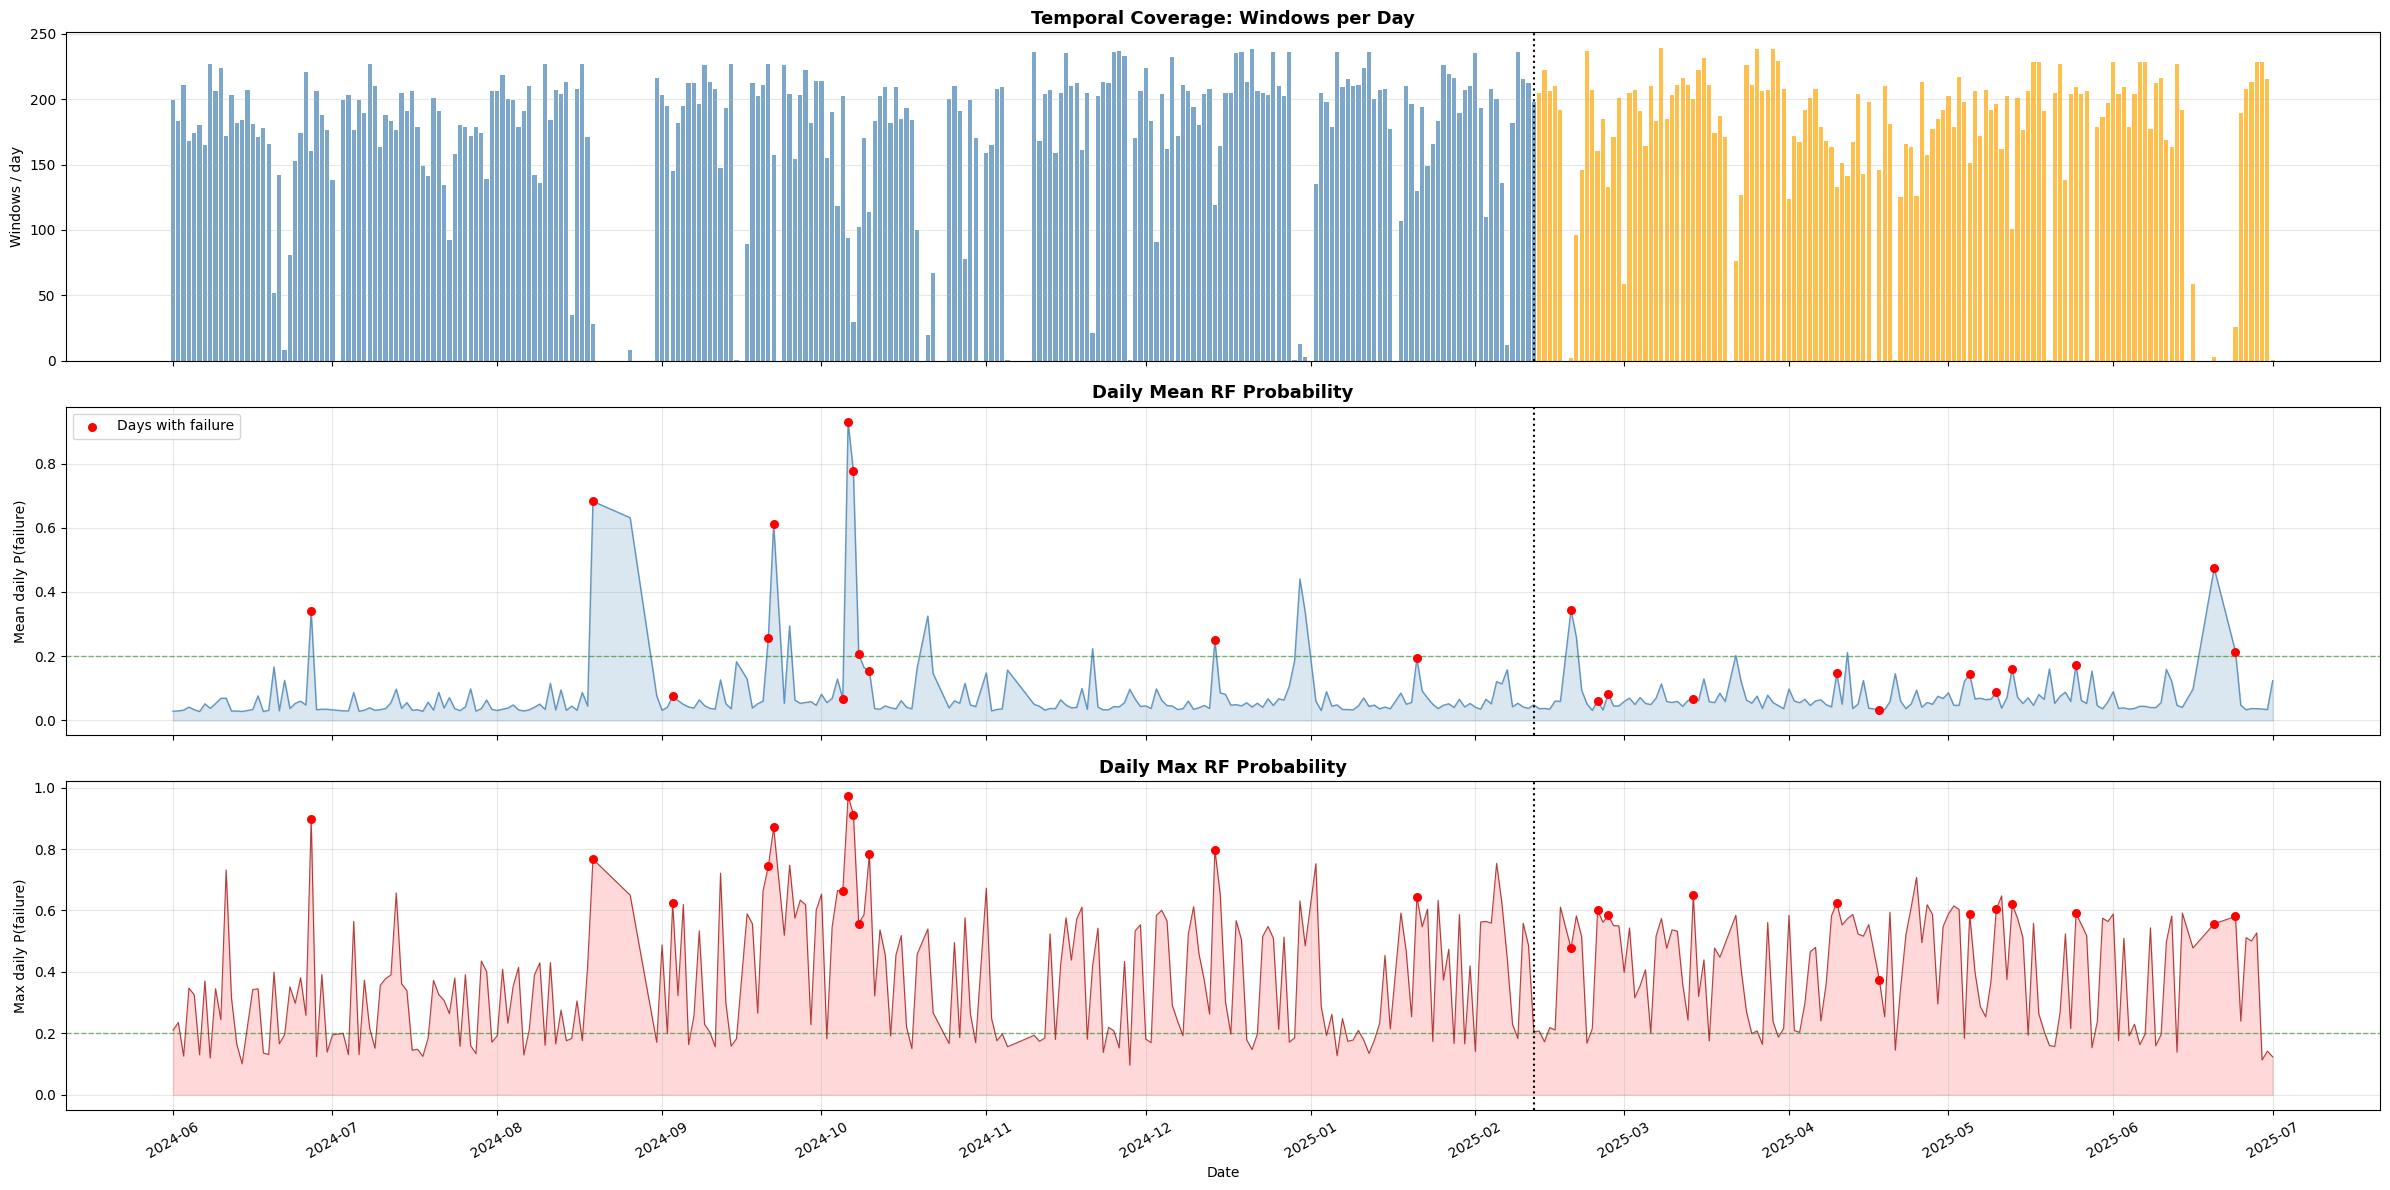

Median window gap: 350s (5.8 min)
Operational breaks (>1h): 571
  Train: 360 | Test: 211
  Median break: 2.8h | Max break: 166.7h

Windows per day: mean=178, median=196


In [12]:
# Windows per day
rf_all['date'] = rf_all['window_end'].dt.date
daily_counts = rf_all.groupby('date').agg(
    n_windows=('prob', 'count'),
    mean_prob=('prob', 'mean'),
    max_prob=('prob', 'max'),
    n_failure=('fail', 'sum'),
    split=('split', 'first')
).reset_index()
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

fig, axes = plt.subplots(3, 1, figsize=(24, 12), sharex=True)

# Windows per day
ax = axes[0]
colors = ['steelblue' if s == 'train' else 'orange' for s in daily_counts['split']]
ax.bar(daily_counts['date'], daily_counts['n_windows'], color=colors, alpha=0.7, width=0.8)
ax.axvline(x=SPLIT_DATE, color='black', linestyle=':', linewidth=1.5)
ax.set_ylabel('Windows / day')
ax.set_title('Temporal Coverage: Windows per Day', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Daily mean probability
ax = axes[1]
ax.plot(daily_counts['date'], daily_counts['mean_prob'], color='steelblue', linewidth=1, alpha=0.8)
ax.fill_between(daily_counts['date'], 0, daily_counts['mean_prob'], alpha=0.2, color='steelblue')
ax.axhline(RF_THR, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=SPLIT_DATE, color='black', linestyle=':', linewidth=1.5)
# Mark failure days
fail_days = daily_counts[daily_counts['n_failure'] > 0]
ax.scatter(fail_days['date'], fail_days['mean_prob'], color='red', s=30, zorder=5, label='Days with failure')
ax.set_ylabel('Mean daily P(failure)')
ax.set_title('Daily Mean RF Probability', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Daily max probability
ax = axes[2]
ax.plot(daily_counts['date'], daily_counts['max_prob'], color='darkred', linewidth=0.8, alpha=0.7)
ax.fill_between(daily_counts['date'], 0, daily_counts['max_prob'], alpha=0.15, color='red')
ax.axhline(RF_THR, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=SPLIT_DATE, color='black', linestyle=':', linewidth=1.5)
ax.scatter(fail_days['date'], fail_days['max_prob'], color='red', s=30, zorder=5)
ax.set_ylabel('Max daily P(failure)')
ax.set_title('Daily Max RF Probability', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Gaps
rf_gaps = rf_all['window_end'].diff().dt.total_seconds()
big_gaps = rf_gaps[rf_gaps > 3600]  # > 1 hour
print(f'Median window gap: {rf_gaps.median():.0f}s ({rf_gaps.median()/60:.1f} min)')
print(f'Operational breaks (>1h): {len(big_gaps)}')
print(f'  Train: {(rf_all.loc[big_gaps.index, "split"]=="train").sum()} | Test: {(rf_all.loc[big_gaps.index, "split"]=="test").sum()}')
print(f'  Median break: {big_gaps.median()/3600:.1f}h | Max break: {big_gaps.max()/3600:.1f}h')
print(f'\nWindows per day: mean={daily_counts["n_windows"].mean():.0f}, median={daily_counts["n_windows"].median():.0f}')

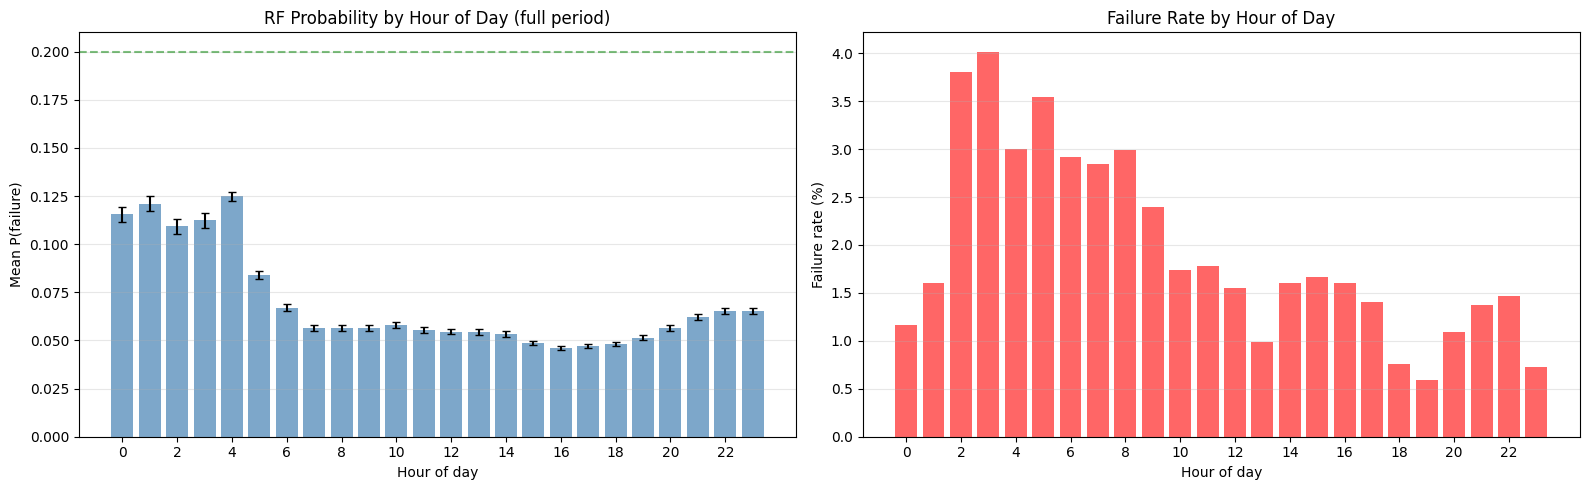

In [13]:
# ── Time-of-day patterns ──
rf_all['hour'] = rf_all['window_end'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean RF prob by hour
ax = axes[0]
hourly = rf_all.groupby('hour')['prob'].agg(['mean', 'std', 'count'])
ax.bar(hourly.index, hourly['mean'], color='steelblue', alpha=0.7)
ax.errorbar(hourly.index, hourly['mean'], yerr=hourly['std']/np.sqrt(hourly['count']),
            fmt='none', color='black', capsize=3)
ax.axhline(RF_THR, color='green', linestyle='--', alpha=0.5)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean P(failure)')
ax.set_title('RF Probability by Hour of Day (full period)')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3, axis='y')

# Failure rate by hour
ax = axes[1]
hourly_fail = rf_all.groupby('hour')['fail'].mean() * 100
ax.bar(hourly_fail.index, hourly_fail.values, color='red', alpha=0.6)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Failure rate (%)')
ax.set_title('Failure Rate by Hour of Day')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [14]:
# ── Summary ──
print('=' * 70)
print('DATASET ANALYSIS SUMMARY (FULL PERIOD)')
print('=' * 70)

print(f'\nPeriod: {rf_all["window_end"].min().date()} to {rf_all["window_end"].max().date()}')
print(f'Train/Test split: {SPLIT_DATE.date()}')

print(f'\n--- Supervised (RF) ---')
print(f'Total windows: {len(rf_all):,} (train: {(rf_all["split"]=="train").sum():,}, test: {(rf_all["split"]=="test").sum():,})')
print(f'Failure windows: {rf_all["fail"].sum():,} ({100*rf_all["fail"].mean():.2f}%)')
print(f'Features: {len(feature_cols)}')
print(f'Threshold: {RF_THR:.3f}')
train_above = (rf_all.loc[rf_all['split']=='train', 'prob'] >= RF_THR).mean()
test_above = (rf_all.loc[rf_all['split']=='test', 'prob'] >= RF_THR).mean()
print(f'Windows above threshold: train={100*train_above:.2f}%, test={100*test_above:.2f}%')

print(f'\n--- Unsupervised (LSTM-AE) ---')
print(f'Total sequences: {len(ae_all):,} (train: {(ae_all["split"]=="train").sum():,}, test: {(ae_all["split"]=="test").sum():,})')
print(f'Channels: {n_channels} | Seq length: {seq_len_sub} (subsampled from {SEQ_WINDOW_S}s)')
for split in ['train', 'test']:
    s = ae_all.loc[ae_all['split']==split, 'score']
    print(f'  {split} scores: mean={s.mean():.4f}, std={s.std():.4f}')

print(f'\n--- Failure Events ---')
print(f'Total: {len(fail_events_all)} (train: {(fail_events_all["period"]=="train").sum()}, test: {(fail_events_all["period"]=="test").sum()})')
for ft in fail_events_all['event_type'].unique():
    n = (fail_events_all['event_type'] == ft).sum()
    print(f'  {ft}: {n}')

print(f'\n--- Anomaly Hotspots (RF) ---')
print(f'Total: {len(hotspots_rf)} (with failure: {hotspots_rf["has_failure"].sum()}, without: {(~hotspots_rf["has_failure"]).sum()})')

print(f'\n--- Subsystem Discriminability ---')
print(f'Features with Cohen\'s d > 0.3: {len(cd_df[cd_df["cohens_d"] > 0.3])} / {len(cd_df)}')
print(f'Within-subsystem mean |corr|: {np.mean(within_vals):.3f}')
print(f'Cross-subsystem mean |corr|: {np.mean(cross_vals):.3f} (ratio: {np.mean(within_vals)/np.mean(cross_vals):.1f}x)')

print(f'\n--- Temporal Coverage ---')
print(f'Windows/day: mean={daily_counts["n_windows"].mean():.0f}, median={daily_counts["n_windows"].median():.0f}')
print(f'Operational breaks (>1h): {len(big_gaps)}')

DATASET ANALYSIS SUMMARY (FULL PERIOD)

Period: 2024-06-01 to 2025-07-01
Train/Test split: 2025-02-12

--- Supervised (RF) ---
Total windows: 64,522 (train: 41,375, test: 23,147)
Failure windows: 1,202 (1.86%)
Features: 340
Threshold: 0.200
Windows above threshold: train=3.43%, test=3.80%

--- Unsupervised (LSTM-AE) ---
Total sequences: 15,246 (train: 9,872, test: 5,374)
Channels: 95 | Seq length: 350 (subsampled from 1402s)
  train scores: mean=0.5388, std=0.2598
  test scores: mean=0.7742, std=0.2834

--- Failure Events ---
Total: 21 (train: 10, test: 11)
  Brake System Failure: 13
  Leveling System Failure: 2
  Compressor Module Failure: 6

--- Anomaly Hotspots (RF) ---
Total: 186 (with failure: 27, without: 159)

--- Subsystem Discriminability ---
Features with Cohen's d > 0.3: 268 / 340
Within-subsystem mean |corr|: 0.567
Cross-subsystem mean |corr|: 0.236 (ratio: 2.4x)

--- Temporal Coverage ---
Windows/day: mean=178, median=196
Operational breaks (>1h): 571
